In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

from  sklearn.linear_model import LinearRegression
from  sklearn.tree import DecisionTreeRegressor
from  sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from  sklearn.metrics import mean_squared_error 
from  sklearn.metrics import r2_score

import warnings
warnings.filterwarnings("ignore")


In [3]:
df = pd.read_csv("D:\laptop_data_cleaned.csv")

In [254]:
df.head()

,Company,TypeName,Ram,Weight,Price,TouchScreen,Ips,Ppi,Cpu_brand,HDD,SSD,Gpu_brand,Os
0,Apple,Ultrabook,8,1.37,11.175755,0,1,226.983005,Intel Core i5,0,128,Intel,Mac
1,Apple,Ultrabook,8,1.34,10.776777,0,0,127.677940,Intel Core i5,0,0,Intel,Mac
2,HP,Notebook,8,1.86,10.329931,0,0,141.211998,Intel Core i5,0,256,Intel,Others
3,Apple,Ultrabook,16,1.83,11.814476,0,1,220.534624,Intel Core i7,0,512,AMD,Mac
4,Apple,Ultrabook,8,1.37,11.473101,0,1,226.983005,Intel Core i5,0,256,Intel,Mac


In [186]:
df.tail()

,Company,TypeName,Ram,Weight,Price,TouchScreen,Ips,Ppi,Cpu_brand,HDD,SSD,Gpu_brand,Os
1268,Asus,Notebook,4,2.20,10.555257,0,0,100.454670,Intel Core i7,500,0,Nvidia,Windows
1269,Lenovo,2 in 1 Convertible,4,1.80,10.433899,1,1,157.350512,Intel Core i7,0,128,Intel,Windows
1270,Lenovo,2 in 1 Convertible,16,1.30,11.288115,1,1,276.053530,Intel Core i7,0,512,Intel,Windows
1271,Lenovo,Notebook,2,1.50,9.409283,0,0,111.935204,Other Intel Processor,0,0,Intel,Windows
1272,HP,Notebook,6,2.19,10.614129,0,0,100.454670,Intel Core i7,1000,0,AMD,Windows


In [187]:
df.columns

Index(['Company', 'TypeName', 'Ram', 'Weight', 'Price', 'TouchScreen', 'Ips',
       'Ppi', 'Cpu_brand', 'HDD', 'SSD', 'Gpu_brand', 'Os'],
      dtype='str')

In [188]:
df.size

16549

In [4]:
print(df["Price"].describe())

count    1273.000000
mean       10.828218
std         0.619565
min         9.134616
25%        10.387379
50%        10.872255
75%        11.287447
max        12.691441
Name: Price, dtype: float64


In [189]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1273 entries, 0 to 1272
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Company      1273 non-null   str    
 1   TypeName     1273 non-null   str    
 2   Ram          1273 non-null   int64  
 3   Weight       1273 non-null   float64
 4   Price        1273 non-null   float64
 5   TouchScreen  1273 non-null   int64  
 6   Ips          1273 non-null   int64  
 7   Ppi          1273 non-null   float64
 8   Cpu_brand    1273 non-null   str    
 9   HDD          1273 non-null   int64  
 10  SSD          1273 non-null   int64  
 11  Gpu_brand    1273 non-null   str    
 12  Os           1273 non-null   str    
dtypes: float64(3), int64(5), str(5)
memory usage: 129.4 KB


In [190]:
df.describe()

,Ram,Weight,Price,TouchScreen,Ips,Ppi,HDD,SSD
count,1273.000000,1273.000000,1273.000000,1273.000000,1273.000000,1273.000000,1273.000000,1273.000000
mean,8.447761,2.041100,10.828218,0.146897,0.279654,146.950812,413.715632,186.252946
std,5.098771,0.669241,0.619565,0.354142,0.449006,42.926775,518.054486,186.531571
min,2.000000,0.690000,9.134616,0.000000,0.000000,90.583402,0.000000,0.000000
25%,4.000000,1.500000,10.387379,0.000000,0.000000,127.335675,0.000000,0.000000
50%,8.000000,2.040000,10.872255,0.000000,0.000000,141.211998,0.000000,256.000000
75%,8.000000,2.310000,11.287447,0.000000,1.000000,157.350512,1000.000000,256.000000
max,64.000000,4.700000,12.691441,1.000000,1.000000,352.465147,2000.000000,1024.000000


In [191]:
for col in df.columns:
    if df[col].nunique() <=10:
        print(f"\nColumn: {col}")
        print(df[col].unique())


Column: TypeName
<StringArray>
[         'Ultrabook',           'Notebook',            'Netbook',
             'Gaming', '2 in 1 Convertible',        'Workstation']
Length: 6, dtype: str

Column: Ram
[ 8 16  4  2 12  6 32 24 64]

Column: TouchScreen
[0 1]

Column: Ips
[1 0]

Column: Cpu_brand
<StringArray>
[        'Intel Core i5',         'Intel Core i7',         'AMD Processor',
         'Intel Core i3', 'Other Intel Processor']
Length: 5, dtype: str

Column: HDD
[   0  500 1000 2000   32  128]

Column: Gpu_brand
<StringArray>
['Intel', 'AMD', 'Nvidia']
Length: 3, dtype: str

Column: Os
<StringArray>
['Mac', 'Others', 'Windows']
Length: 3, dtype: str


In [192]:
df.isnull().sum()

Company        0
TypeName       0
Ram            0
Weight         0
Price          0
TouchScreen    0
Ips            0
Ppi            0
Cpu_brand      0
HDD            0
SSD            0
Gpu_brand      0
Os             0
dtype: int64

In [193]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 1


In [194]:
df = df.drop_duplicates()

In [195]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


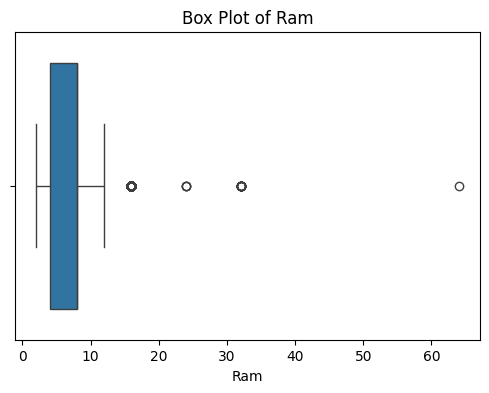

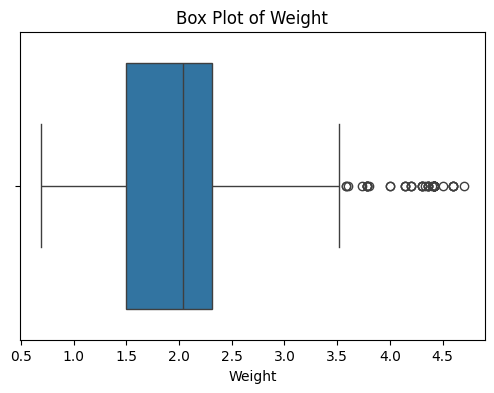

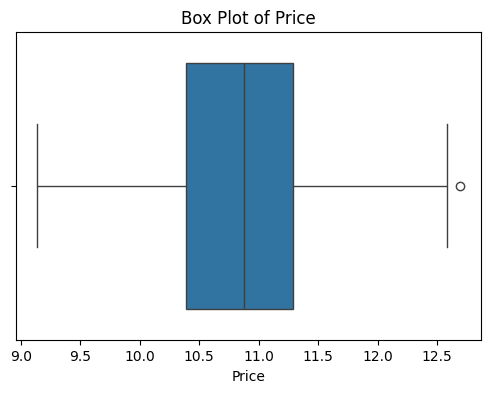

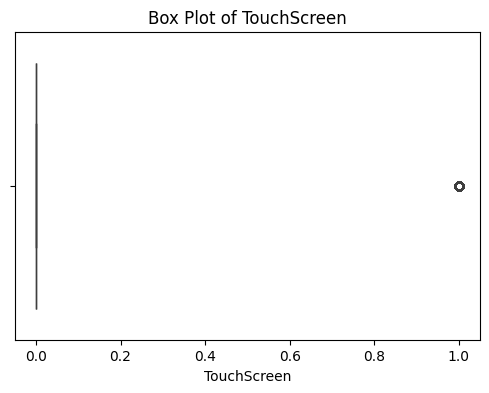

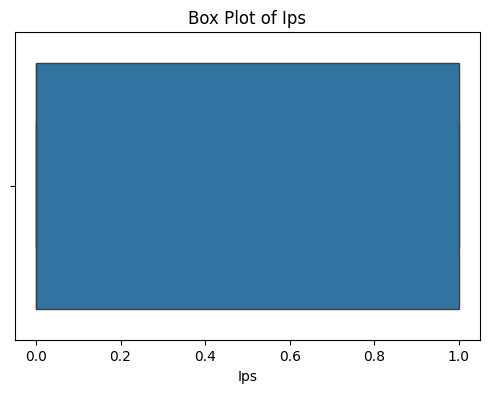

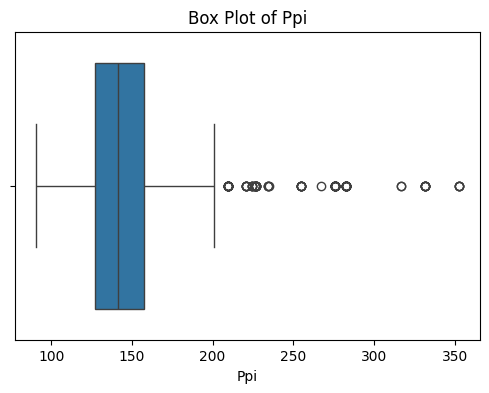

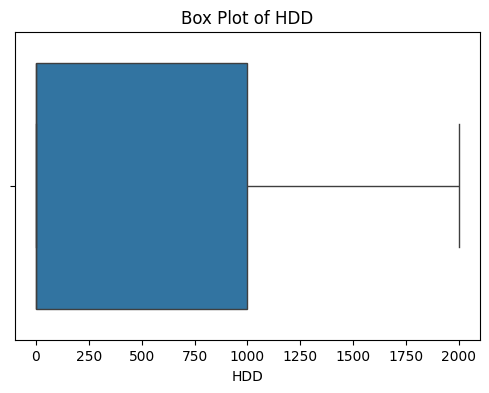

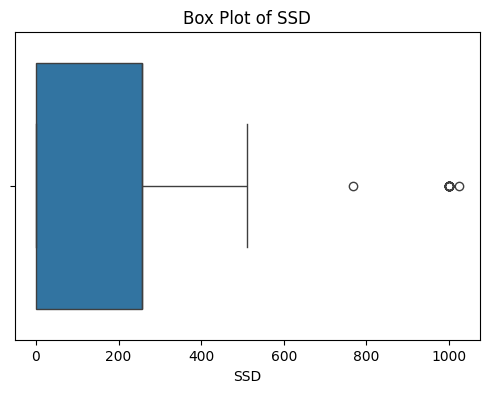

In [196]:
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
for col in numerical_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Box Plot of {col}")
    plt.show()

In [197]:
for col in["Ram","Weight","Price","Ppi","SSD"]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower) & (df[col] <= upper)]

<Axes: ylabel='Ram'>

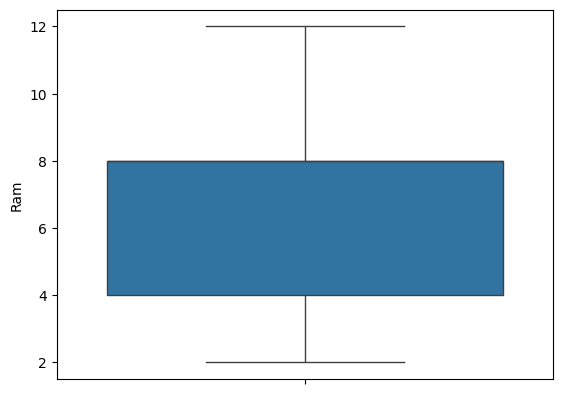

In [198]:
sns.boxplot(data=df["Ram"])


<Axes: ylabel='Weight'>

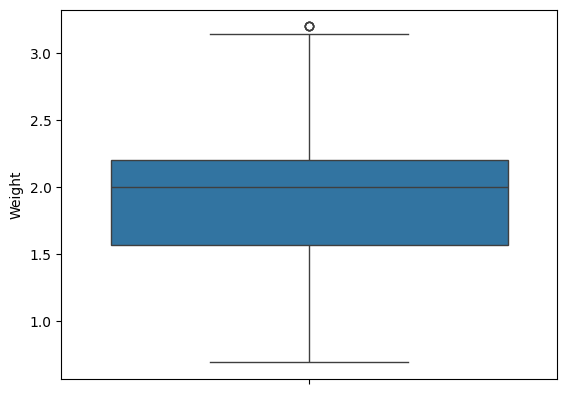

In [199]:
sns.boxplot(df["Weight"])

<Axes: ylabel='Price'>

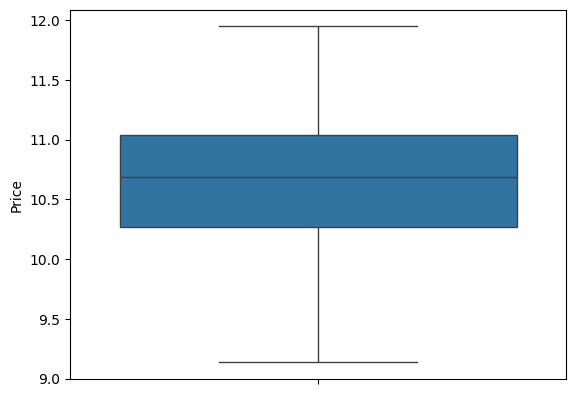

In [200]:
sns.boxplot(df["Price"])

<Axes: ylabel='Ppi'>

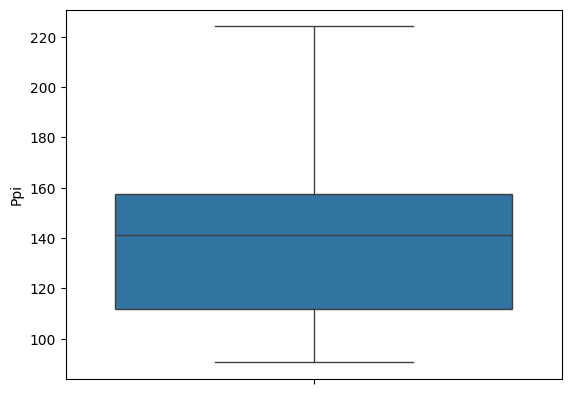

In [201]:
sns.boxplot(df["Ppi"])

<Axes: ylabel='SSD'>

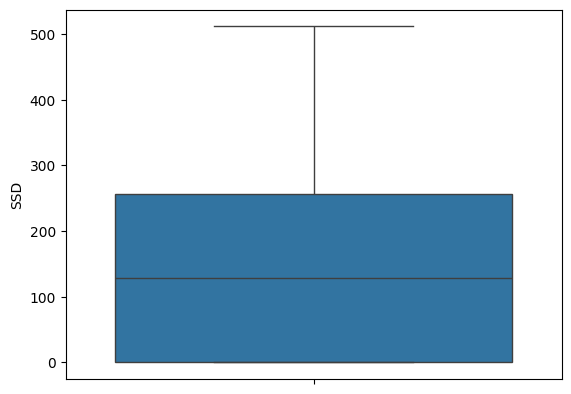

In [202]:
sns.boxplot(df["SSD"])

In [203]:
numeric_df = df.select_dtypes(include='number')
corr = numeric_df.corr()
corr

,Ram,Weight,Price,TouchScreen,Ips,Ppi,HDD,SSD
Ram,1.000000,0.075458,0.654294,0.107693,0.219721,0.349918,0.023731,0.459422
Weight,0.075458,1.000000,-0.119745,-0.305370,-0.154420,-0.512032,0.529815,-0.283001
Price,0.654294,-0.119745,1.000000,0.159580,0.261186,0.529576,-0.195372,0.608370
TouchScreen,0.107693,-0.305370,0.159580,1.000000,0.220687,0.347499,-0.137925,0.153857
Ips,0.219721,-0.154420,0.261186,0.220687,1.000000,0.373065,-0.133587,0.252847
Ppi,0.349918,-0.512032,0.529576,0.347499,0.373065,1.000000,-0.379416,0.508061
HDD,0.023731,0.529815,-0.195372,-0.137925,-0.133587,-0.379416,1.000000,-0.579743
SSD,0.459422,-0.283001,0.608370,0.153857,0.252847,0.508061,-0.579743,1.000000


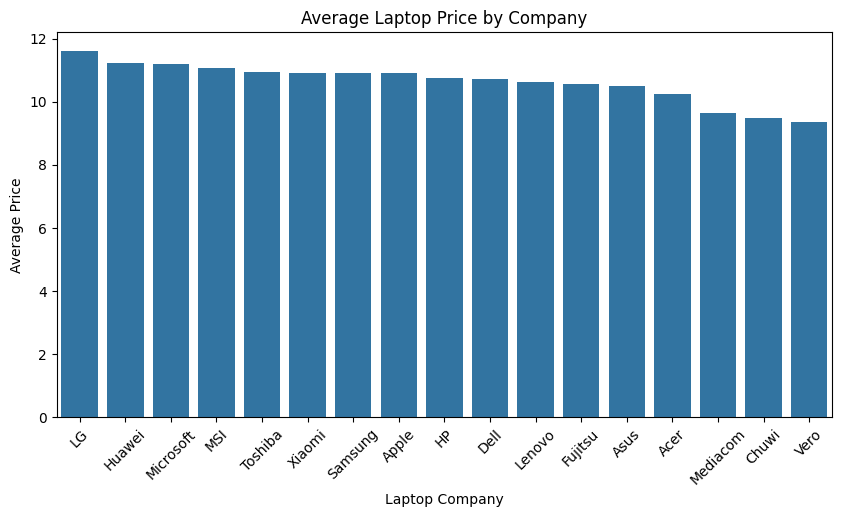

In [204]:
avg_price = df.groupby("Company")["Price"].mean().sort_values(ascending=False)
plt.figure(figsize=(10,5))
sns.barplot(x=avg_price.index,y=avg_price.values)
plt.xlabel("Laptop Company")
plt.ylabel("Average Price")
plt.title("Average Laptop Price by Company")
plt.xticks(rotation=45)
plt.show()

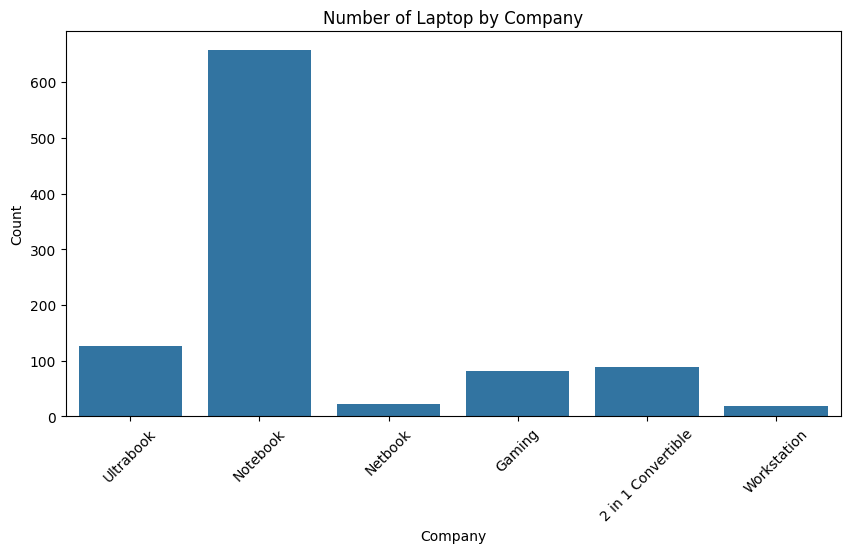

In [205]:
plt.figure(figsize=(10,5))
sns.countplot(x="TypeName",data=df)
plt.xlabel("Company")
plt.ylabel("Count")
plt.title("Number of Laptop by Company")
plt.xticks(rotation=45)
plt.show()

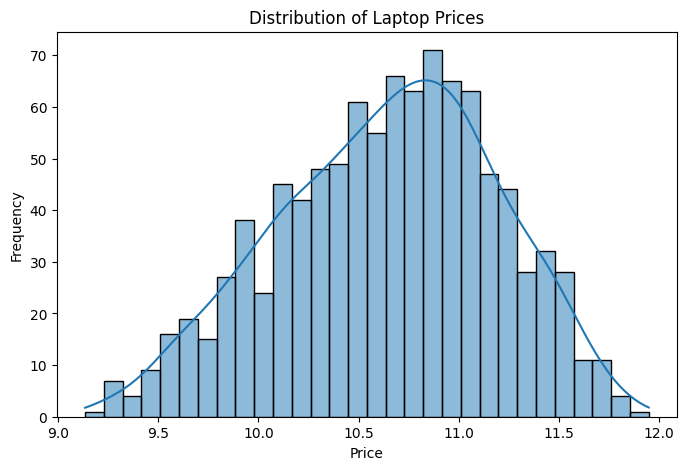

In [206]:
plt.figure(figsize=(8,5))
sns.histplot(df["Price"],bins=30,kde=True)
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Distribution of Laptop Prices")
plt.show()

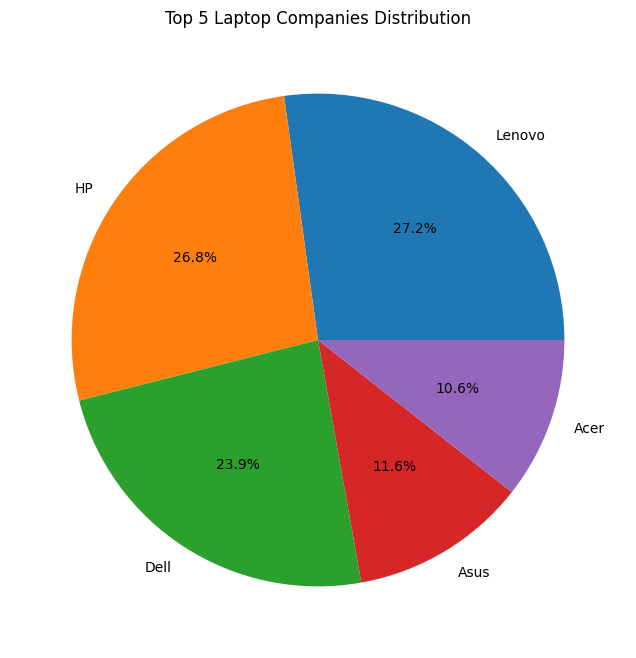

In [207]:
top5 = df["Company"].value_counts().head(5)
plt.figure(figsize=(8,8))
plt.pie(top5,labels=top5.index,autopct="%1.1f%%")
plt.title("Top 5 Laptop Companies Distribution")
plt.show()

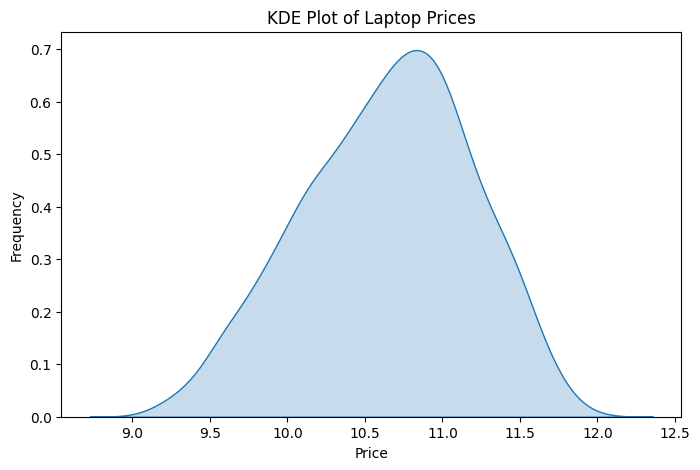

In [208]:
plt.figure(figsize=(8,5))
sns.kdeplot(df["Price"],fill=True)
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("KDE Plot of Laptop Prices")
plt.show()

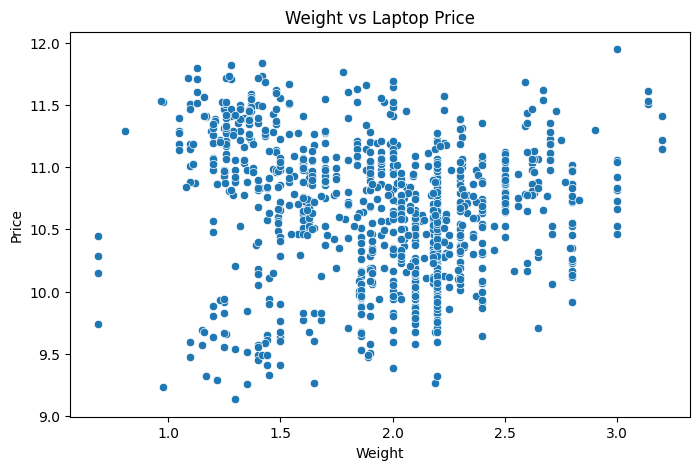

In [212]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="Weight",y="Price",data=df)
plt.xlabel("Weight")
plt.ylabel("Price")
plt.title("Weight vs Laptop Price")
plt.show()

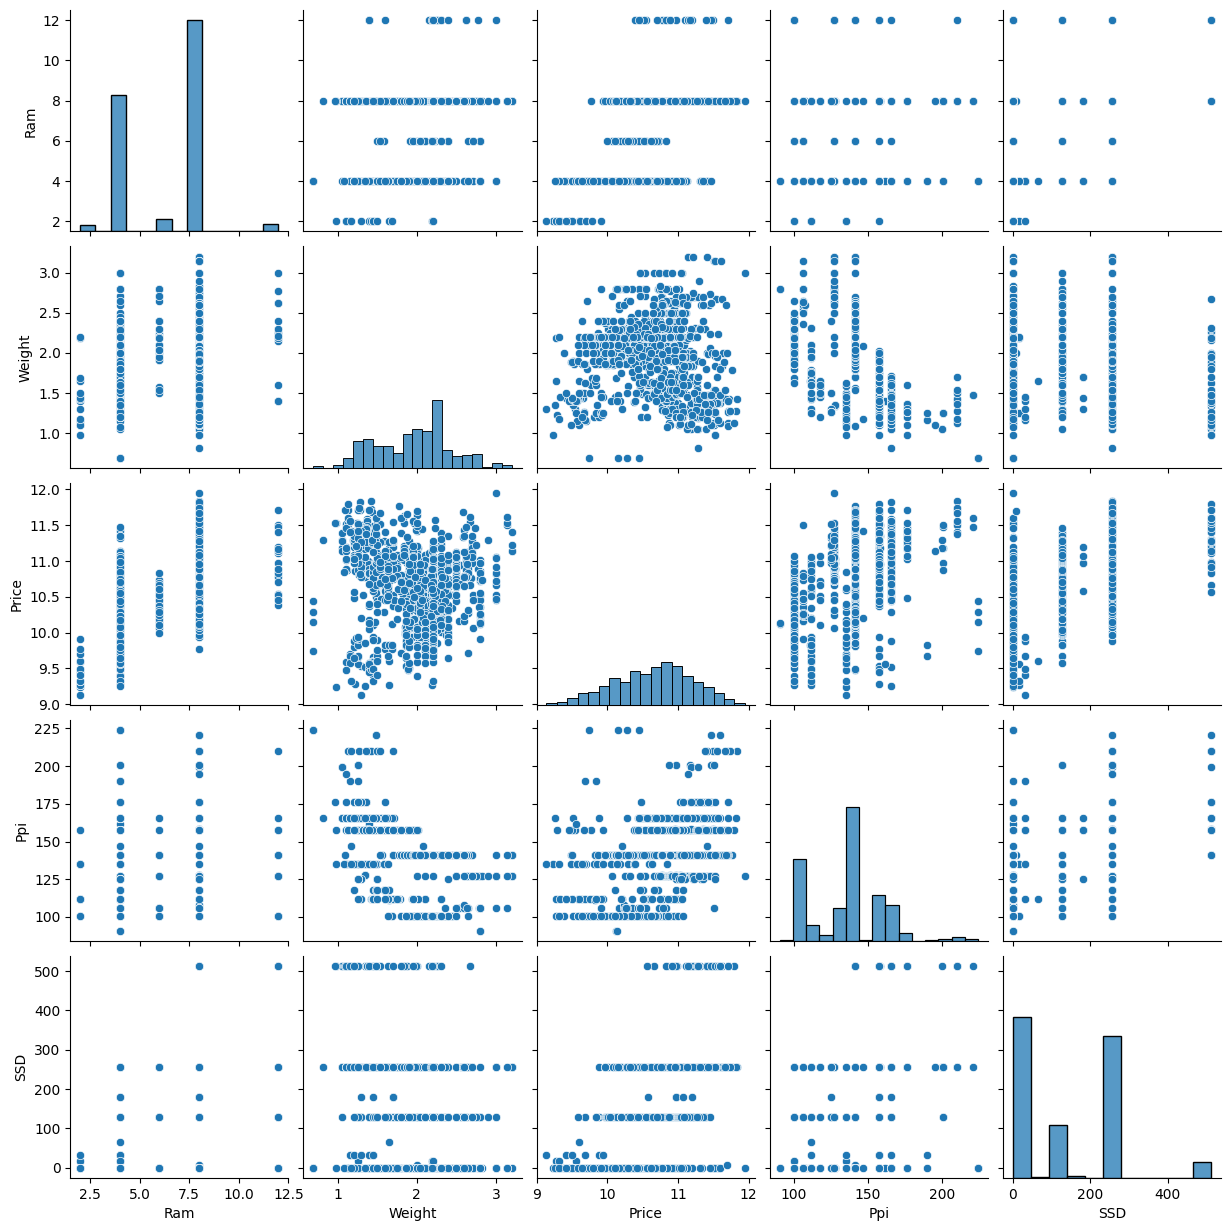

In [213]:
cols = ["Ram","Weight","Price","Ppi","SSD"]
sns.pairplot(df[cols])
plt.show()

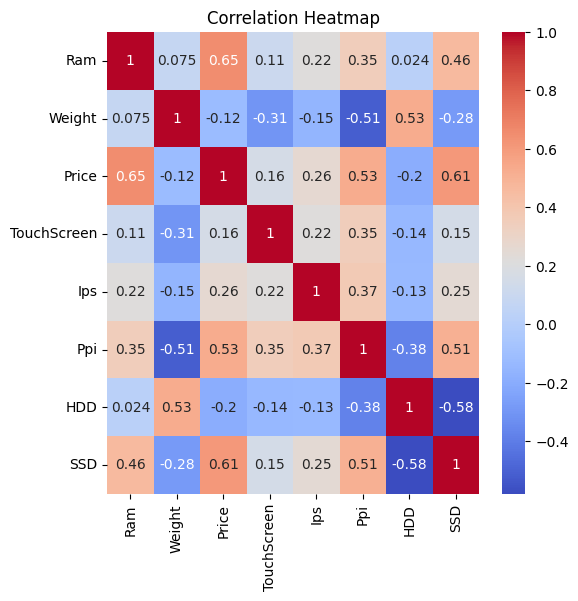

In [214]:
plt.figure(figsize=(6,6))
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [215]:
print(df.select_dtypes(include="object").columns)

Index(['Company', 'TypeName', 'Cpu_brand', 'Gpu_brand', 'Os'], dtype='str')


In [ ]:
encoder = LabelEncoder()

df["Company"] = encoder.fit_transform(df["Company"])

df["TypeName"] = encoder.fit_transform(df["TypeName"])

df["Cpu_brand"] = encoder.fit_transform(df["Cpu_brand"])
df["Gpu_brand"] = encoder.fit_transform(df["Gpu_brand"])
df["Os"] = encoder.fit_transform(df["Os"])

df.head()


,Company,TypeName,Ram,Weight,Price,TouchScreen,Ips,Ppi,Cpu_brand,HDD,SSD,Gpu_brand,Os
1,1,4,8,1.34,10.776777,0,0,127.677940,2,0,0,1,0
2,6,3,8,1.86,10.329931,0,0,141.211998,2,0,256,1,1
5,0,3,4,2.10,9.967026,0,0,100.454670,0,500,0,0,2
7,1,4,8,1.34,11.030615,0,0,127.677940,2,0,0,1,0
9,0,4,8,1.60,10.621952,0,1,157.350512,2,0,256,1,2


In [ ]:
X = df.drop("Price",axis=1)
y = df["Price"]


In [232]:
X = pd.get_dummies(X, drop_first=True)

In [233]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled,columns=X.columns)
X_scaled.head()

,Company,TypeName,Ram,Weight,TouchScreen,Ips,Ppi,Cpu_brand,HDD,SSD,Gpu_brand,Os
0,-1.380091,1.145988,0.723190,-1.300566,-0.361705,-0.556433,-0.350955,-0.279318,-0.792133,-0.992608,-0.120328,-4.943707
1,0.045611,0.258138,0.723190,-0.187647,-0.361705,-0.556433,0.187782,-0.279318,-0.792133,0.847356,-0.120328,-2.267212
2,-1.665231,0.258138,-1.158619,0.326008,-0.361705,-0.556433,-1.434607,-2.214107,0.213050,-0.992608,-1.736624,0.409283
3,-1.380091,1.145988,0.723190,-1.300566,-0.361705,-0.556433,-0.350955,-0.279318,-0.792133,-0.992608,-0.120328,-4.943707
4,-1.665231,1.145988,0.723190,-0.744106,-0.361705,1.797161,0.830194,-0.279318,-0.792133,0.847356,-0.120328,0.409283


In [234]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [237]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
print("R^2 Score :", r2_score(y_test, lr_pred))

R^2 Score : 0.6790390006026278


In [236]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
print("R^2 Score :", r2_score(y_test, dt_pred))

R^2 Score : 0.791212849993318


In [247]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print("R^2 Score :", r2_score(y_test, rf_pred))

R^2 Score : 0.860352121609973


In [268]:
print("Linear Regression :", r2_score(y_test, lr_pred))
print("Decision Tree :", r2_score(y_test, dt_pred))
print("Random Forest :",r2_score(y_test, rf_pred))


Linear Regression : 0.6790390006026278
Decision Tree : 0.791212849993318
Random Forest : 0.860352121609973


In [269]:
print("MAE :",mean_absolute_error(y_test,rf_pred))
print("MSE :",mean_squared_error(y_test,rf_pred))
print("RMSE :",np.sqrt(mean_squared_error(y_test,rf_pred)))


MAE : 0.01315824385517492
MSE : 0.0003231817769446405
RMSE : 0.01797725721417593


In [ ]:
new_laptop = pd.DataFrame({"Company":["Lenovo"],
                           "TypeName":["Ultrabook"],
                           "Ram":[8],
                           "Weight":[1.37],
                           "TouchScreen":[0],
                           "Ips":[1],
                           "Ppi":[226.983],
                          "Cpu_brand":["IntelCore"],
                          "HDD":[0],
                          "SSD":[128],
                          "Gpu_brand":["Intel"],
                          "Os":["Mac"]
                          })
# Encode categorical columns
new_laptop["Company"] = encoder.fit_transform(new_laptop["Company"])
new_laptop["TypeName"] = encoder.fit_transform(new_laptop["TypeName"])
new_laptop["Cpu_brand"] = encoder.fit_transform(new_laptop["Cpu_brand"])
new_laptop["Gpu_brand"] = encoder.fit_transform(new_laptop["Gpu_brand"])
new_laptop["Os"] = encoder.fit_transform(new_laptop["Os"])

# Align columns with training data
missing_cols = set(X.columns) - set(new_laptop.columns)
for col in missing_cols:
    new_laptop[col] = 0
new_laptop = new_laptop[X.columns]

# Scale the data
new_laptop_scaled = scaler.transform(new_laptop)
predicted_price = rf.predict(new_laptop_scaled)
predicted_price = model.predict(new_laptop)
predicted_price = np.expm1(predicted_price)
print("Predicted Laptop Price:",predicted_price[0])


Predicted Laptop Price: 10.706678312862701
